# Predict whether the Employee of an Organization should get Promotion or Not?

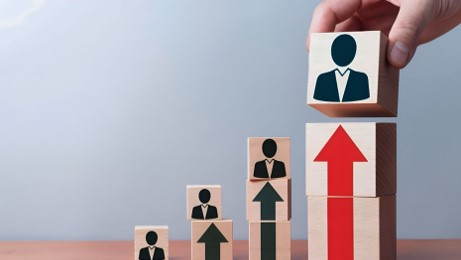

Importing all the Required Libraries

We Imported Numpy, Pandas, Matplot, and Seaborn for Data Analysis and Visualizations

In [ ]:
import numpy as np
# for dataframe operations
import pandas as pd

# for data visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# setting up the size of the figures
plt.rcParams['figure.figsize'] = (16, 5)
# setting up the style of the plot
plt.style.use('fivethirtyeight')

# for interactivity
import ipywidgets as widgets
from ipywidgets import interact
from ipywidgets import interact_manual


Reading the Datasets

In [ ]:
train = pd.read_csv('train_dataset.csv')
test = pd.read_csv('test_dataset.csv')

In [ ]:
# lets check the shape of the train and test datasets
print("Shape of the Training Data :", train.shape)
print("Shape of the Test Data :", test.shape)

Shape of the Training Data : (54808, 14)
Shape of the Test Data : (10962, 13)


In [ ]:
# lets check the head of the dataset
train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [ ]:
# lets check the head of the test data
test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [ ]:
# lets also check the tail of the test data
train.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,0,78,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,0,56,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,1,0,79,0
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,0,45,0
54807,51526,HR,region_22,Bachelor's,m,other,1,27,1.0,5,0,0,49,0


In [ ]:
# lets also check the tail of the test data
test.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,0,61
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,0,74
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,0,50
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,NaN,1,0,0,70
23489,5973,Technology,region_17,Master's & above,m,other,3,40,5.0,5,1,0,89


In [ ]:
# lets check the datatype of the columns in the data
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


# Exploratory Analysis

The plot shows counts of of employees who were promoted and performance of employees who were not promoted

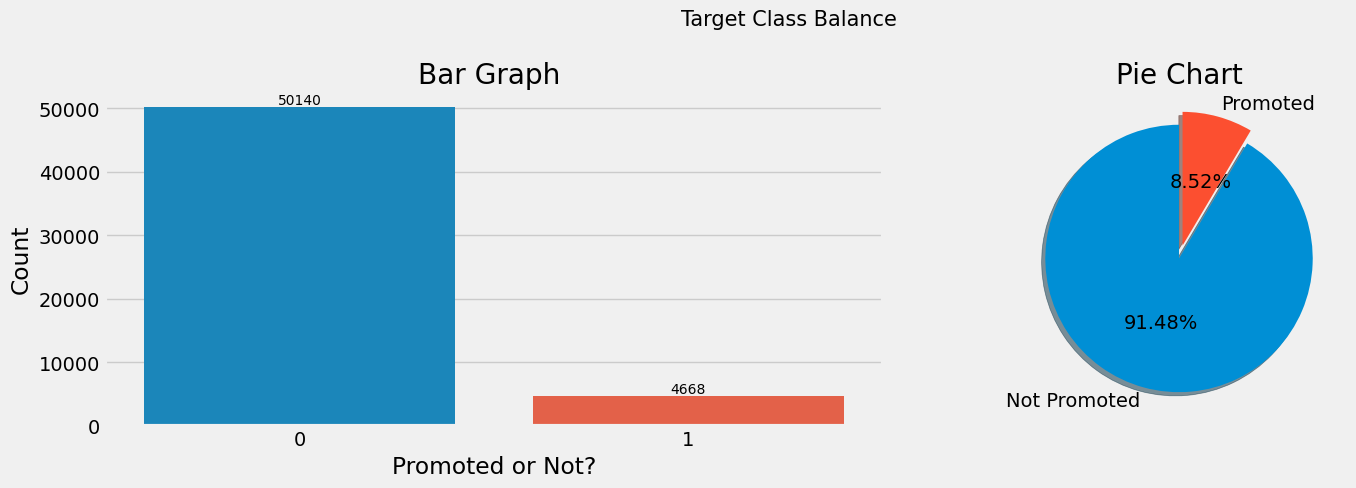

In [ ]:

# Create subplots
fig, axes = plt.subplots(1, 2)

# Bar graph (subplot 1)
value_counts = train['is_promoted'].value_counts()
sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[0])
axes[0].set_title('Bar Graph ')
axes[0].set_xlabel('Promoted or Not?')
axes[0].set_ylabel('Count')

# Add labels on top of the bars
for i, v in enumerate(value_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=10)

# Pie chart (subplot 2)
train['is_promoted'].value_counts().plot(
    kind='pie', explode=[0, 0.1], autopct='%.2f%%', startangle=90,
    labels=['Not Promoted', 'Promoted'], shadow=True, pctdistance=0.5, ax=axes[1])
axes[1].set_title('Pie Chart')
axes[1].axis('off')

# Set the title for the entire plot
plt.suptitle('Target Class Balance', fontsize=15)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# lets check descriptive statistics for numerical columns
train.iloc[:,1:].describe().style.background_gradient(cmap = 'copper')

,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [ ]:
# lets check descriptive statistics for categorical columns
train.describe(include = 'object')

,department,region,education,gender,recruitment_channel
count,54808,54808,52399,54808,54808
unique,9,34,3,2,3
top,Sales & Marketing,region_2,Bachelor's,m,other
freq,16840,12343,36669,38496,30446


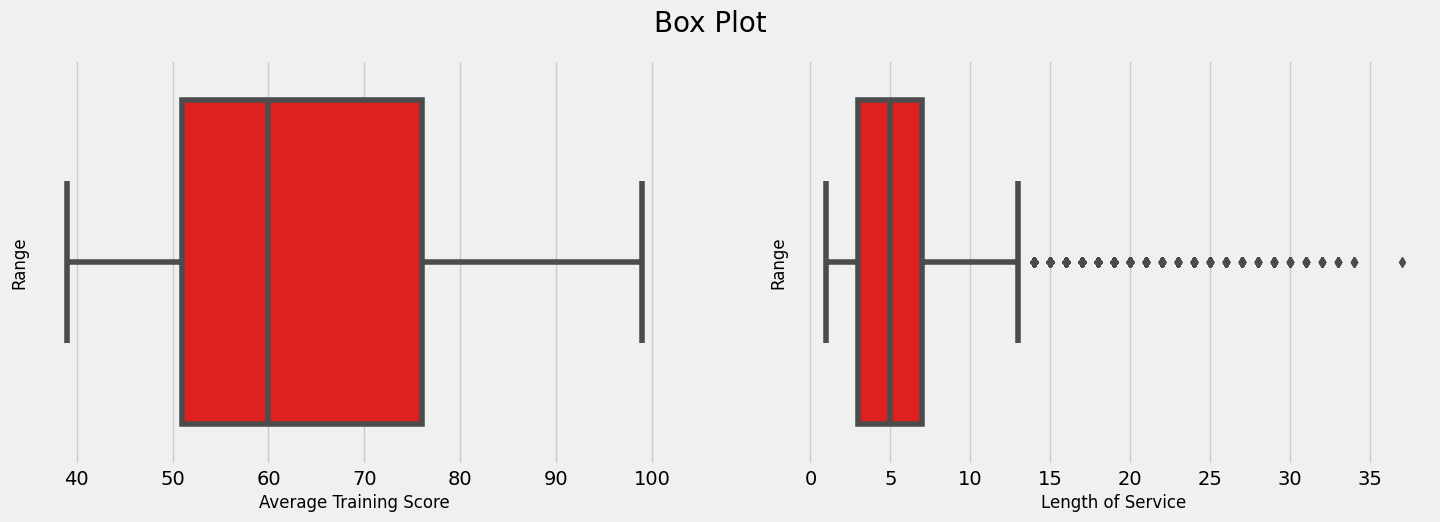

In [ ]:
# Box plot for average training score (horizontal)
plt.subplot(1, 2, 1)
sns.boxplot(x=train['avg_training_score'], color='red', orient='h')
plt.ylabel('Range', fontsize=12)
plt.xlabel('Average Training Score', fontsize=12)

# Box plot for length of service (horizontal)
plt.subplot(1, 2, 2)
sns.boxplot(x=train['length_of_service'], color='red', orient='h')
plt.ylabel('Range', fontsize=12)
plt.xlabel('Length of Service', fontsize=12)

plt.suptitle('Box Plot', fontsize=20)
plt.show()


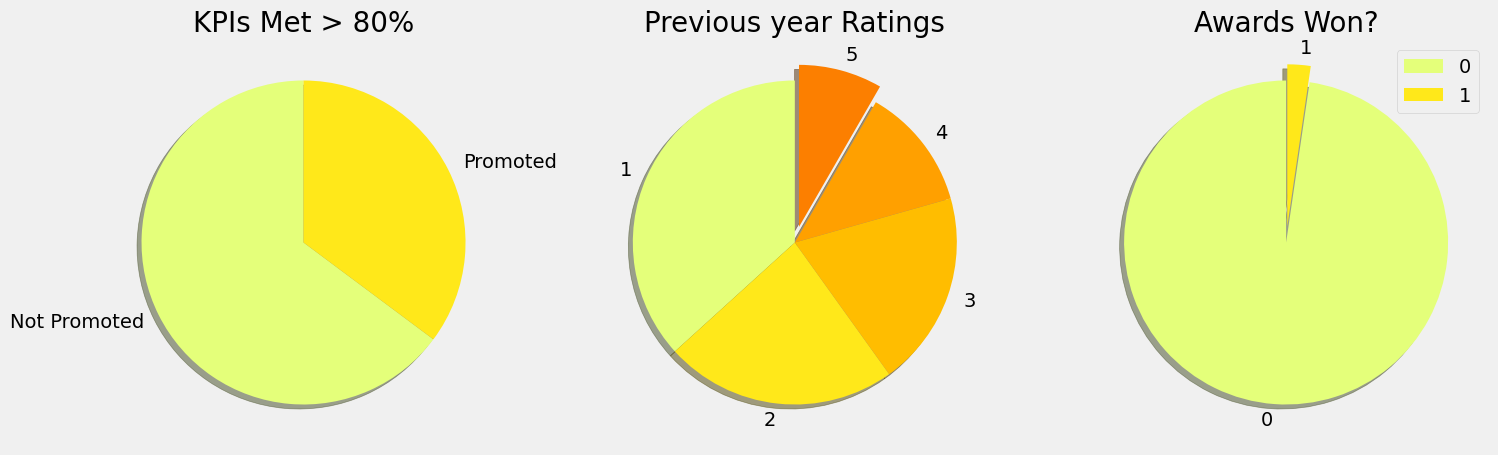

In [ ]:
# lets plot pie chart for the columns where we have very few categories
plt.rcParams['figure.figsize'] = (16,5)
plt.style.use('fivethirtyeight')

# plotting a pie chart to represent share of Previous year Rating of the Employees
plt.subplot(1, 3, 1)
labels = ['Not Promoted','Promoted']
sizes = train['KPIs_met >80%'].value_counts()
colors = plt.cm.Wistia(np.linspace(0, 1, 5))
explode = [0, 0]

plt.pie(sizes, labels = labels, colors = colors, explode = explode, shadow = True, startangle = 90)
plt.title('KPIs Met > 80%', fontsize = 20)

# plotting a pie chart to represent share of Previous year Rating of the Employees
plt.subplot(1, 3, 2)
labels = ['1', '2', '3', '4', '5']
sizes = train['previous_year_rating'].value_counts()
colors = plt.cm.Wistia(np.linspace(0, 1, 5))
explode = [0, 0, 0, 0, 0.1]

plt.pie(sizes, labels = labels, colors = colors, explode = explode, shadow = True, startangle = 90)
plt.title('Previous year Ratings', fontsize = 20)

# plotting a pie chart to represent share of Previous year Rating of the Employees
plt.subplot(1, 3, 3)
labels = ['0', '1']
sizes = train['awards_won?'].value_counts()
colors = plt.cm.Wistia(np.linspace(0, 1, 5))
explode = [0,0.1]

plt.pie(sizes, labels = labels, colors = colors, explode = explode, shadow = True, startangle = 90)
plt.title('Awards Won?', fontsize = 20)


plt.legend()
plt.show()

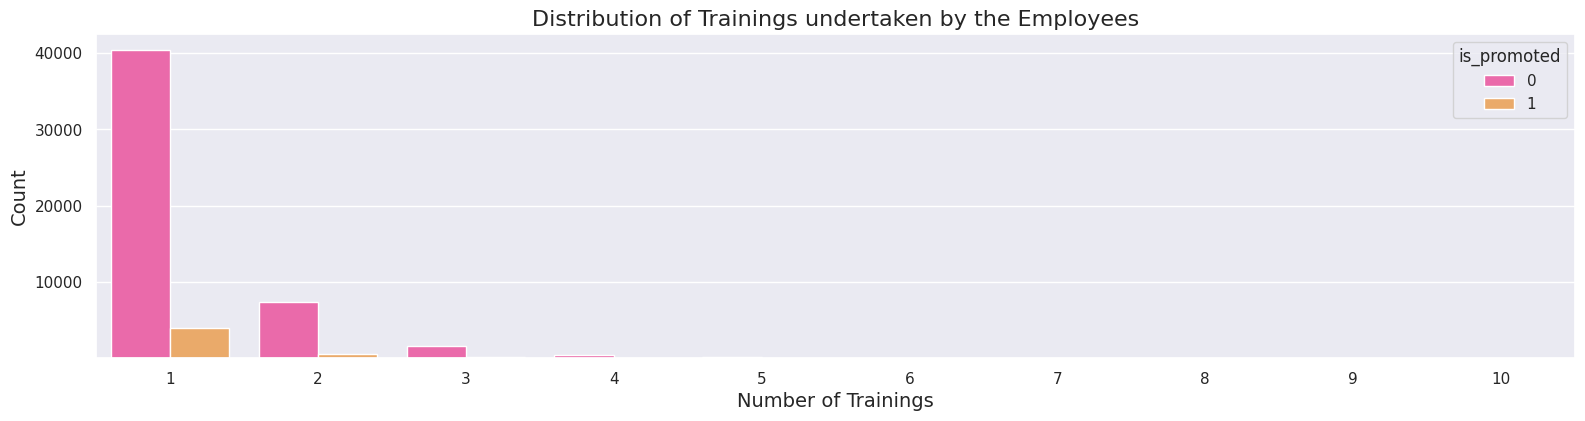

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the size of the plot
plt.rcParams['figure.figsize'] = (17, 4)

# Set the height of the bars
sns.set(rc={'figure.figsize':(17, 4)})

# Create a count plot for the distribution of trainings with hue
ax = sns.countplot(data=train, x='no_of_trainings', hue='is_promoted', palette='spring')

# Set x-axis label
plt.xlabel('Number of Trainings', fontsize=14)

# Set y-axis label
plt.ylabel('Count', fontsize=14)

# Set y-axis ticks
plt.yticks([10000, 20000, 30000, 40000])

# Set title
plt.title('Distribution of Trainings undertaken by the Employees', fontsize=16)

# Show the plot
plt.show()


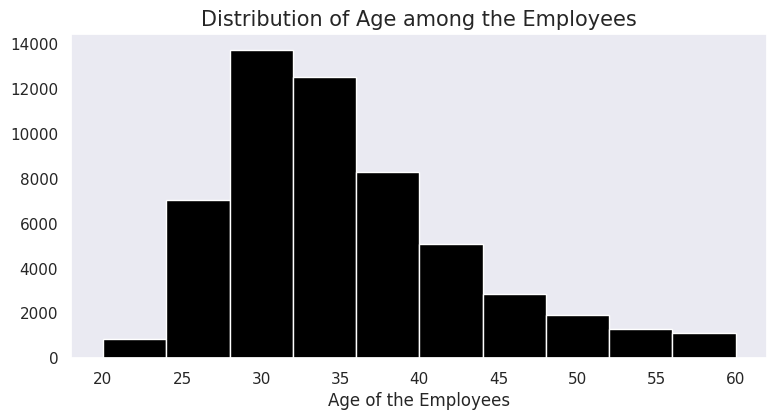

In [ ]:
# lets check the Age of the Employees

plt.rcParams['figure.figsize'] = (8, 4)
plt.hist(train['age'], color = 'black')
plt.title('Distribution of Age among the Employees', fontsize = 15)
plt.xlabel('Age of the Employees')
plt.grid()
plt.show()

In [ ]:
train['age_label'] = pd.cut(train.age,bins=[0,25,40,50,100],labels=['Young','Middle','Senior','Elder'])
train.head(5)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,age_label
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0,Middle
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0,Middle
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0,Middle
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0,Middle
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0,Senior


In [ ]:
ages = train.pivot_table(values='is_promoted',index='age_label')
ages

,is_promoted
age_label,
Young,0.066357
Middle,0.090173
Senior,0.072727
Elder,0.066971


Text(0.5, 0, 'age category')

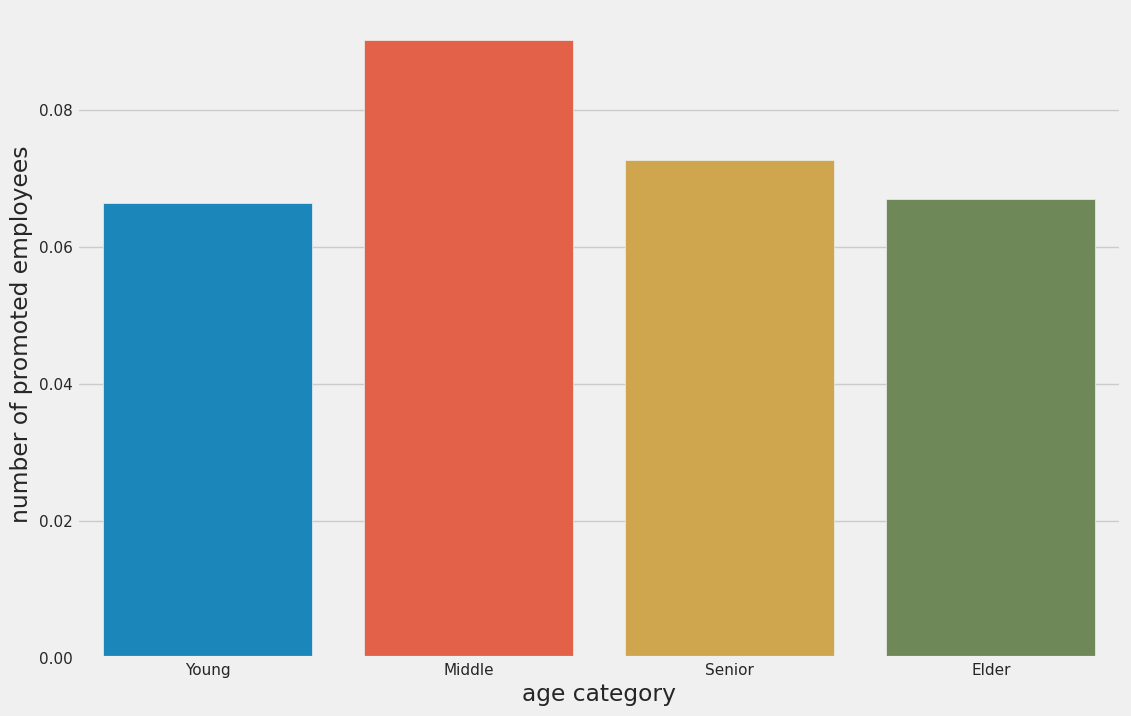

In [ ]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(12,8))
sns.barplot(
    x=ages.index,
    y=ages.is_promoted
)
plt.ylabel('number of promoted employees')
plt.xlabel('age category')

**An employee aged between 25 and 40 years is likely to be promoted**

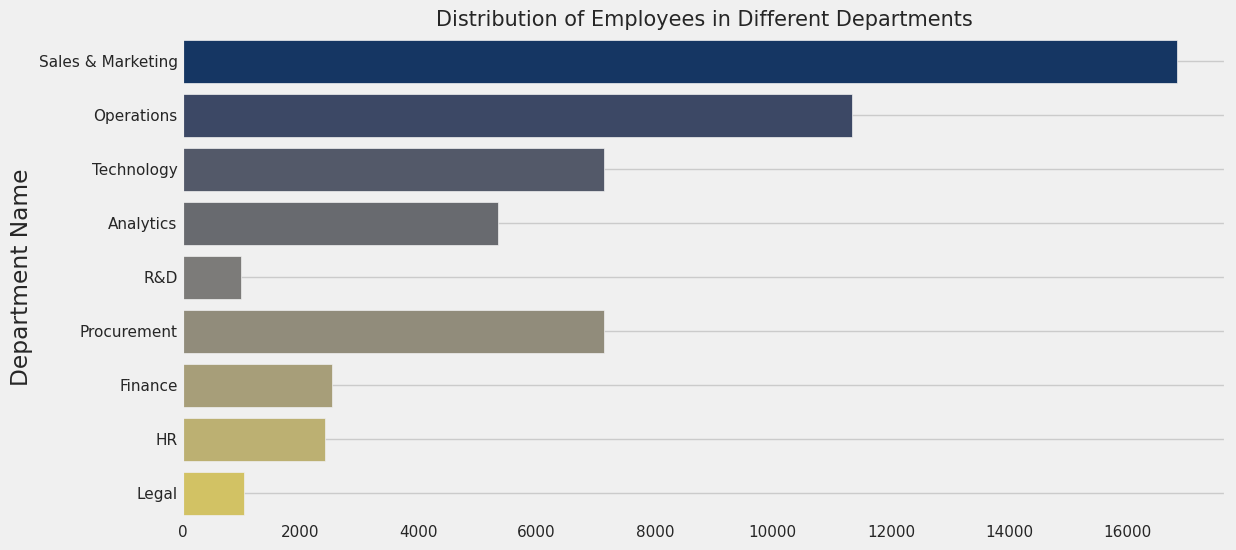

In [ ]:
# lets check count of employees in different Departments

plt.rcParams['figure.figsize'] = (12, 6)
sns.countplot(y = train['department'], palette = 'cividis', orient = 'v')
plt.xlabel('')
plt.ylabel('Department Name')
plt.title('Distribution of Employees in Different Departments', fontsize = 15)
plt.grid()

plt.show()

In [ ]:
def decode(val):
    if val == 0:
        return 'New'
    elif val == 1:
        return 'Minimum'
    elif val == 2:
        return 'Fair'
    elif val == 3:
        return 'Improving'
    elif val == 4:
        return 'Good'
    else:
        return 'Very good'

train['rating_label'] = train.previous_year_rating.apply(decode)
train.head(5)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,age_label,rating_label
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0,Middle,Very good
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0,Middle,Very good
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0,Middle,Improving
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0,Middle,Minimum
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0,Senior,Improving


In [ ]:
ratings = train.pivot_table(values='is_promoted',index='rating_label')
ratings

,is_promoted
rating_label,
Fair,0.042840
Good,0.079376
Improving,0.072779
Minimum,0.014141
Very good,0.142452


Text(0.5, 0, 'ratings')

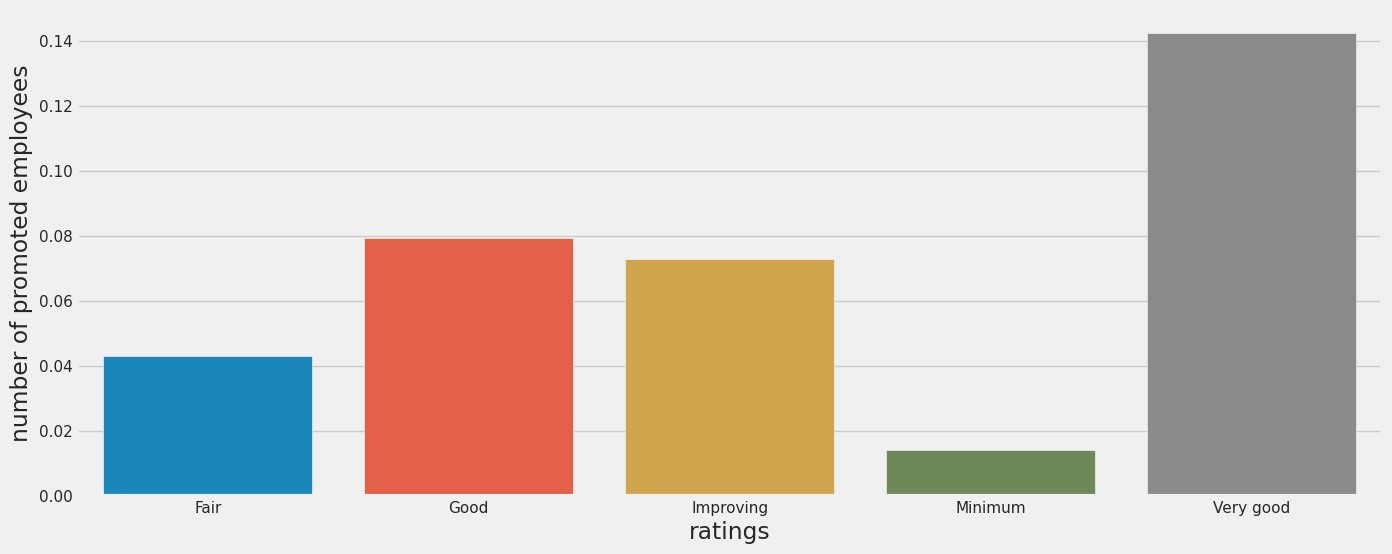

In [ ]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(15,6))
sns.barplot(
    x=ratings.index,
    y=ratings.is_promoted
)
plt.ylabel('number of promoted employees')
plt.xlabel('ratings')

**Employees with 'Very good' rating (5) are most likely to be promoted.**

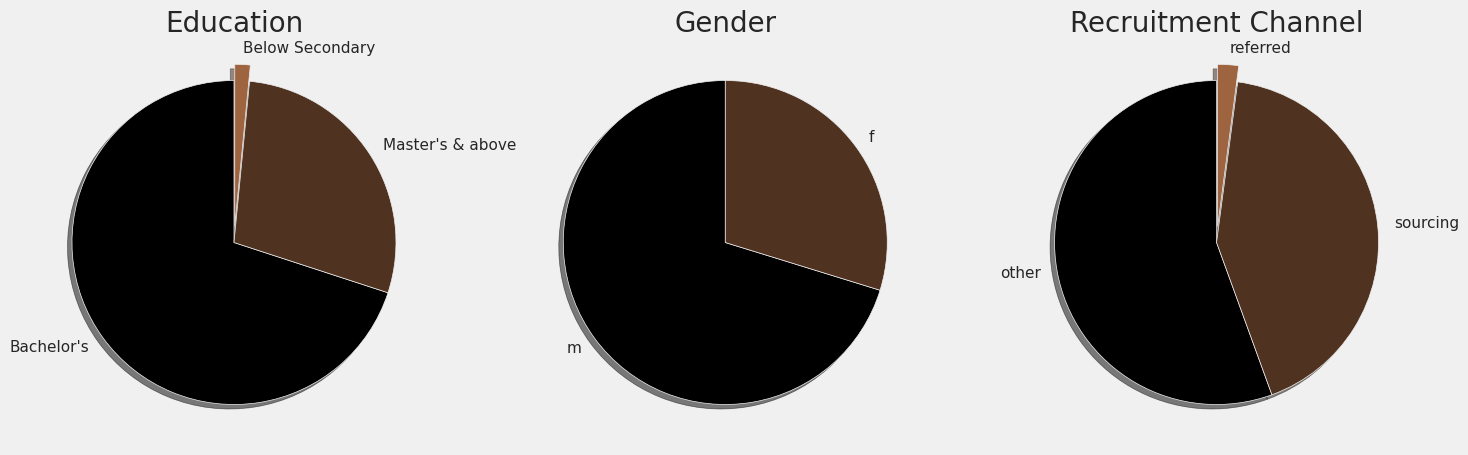

In [ ]:
# lets plot pie chart for the columns where we have very few categories
plt.rcParams['figure.figsize'] = (16,5)

# plotting a pie chart to represent share of Previous year Rating of the Employees
plt.subplot(1, 3, 1)
labels = train['education'].value_counts().index
sizes = train['education'].value_counts()
colors = plt.cm.copper(np.linspace(0, 1, 5))
explode = [0, 0, 0.1]

plt.pie(sizes, labels = labels, colors = colors, explode = explode, shadow = True, startangle = 90)
plt.title('Education', fontsize = 20)

# plotting a pie chart to represent share of Previous year Rating of the Employees
plt.subplot(1, 3, 2)
labels = train['gender'].value_counts().index
sizes = train['gender'].value_counts()
colors = plt.cm.copper(np.linspace(0, 1, 5))
explode = [0, 0]

plt.pie(sizes, labels = labels, colors = colors, explode = explode, shadow = True, startangle = 90)
plt.title('Gender', fontsize = 20)

# plotting a pie chart to represent share of Previous year Rating of the Employees
plt.subplot(1, 3, 3)
labels = train['recruitment_channel'].value_counts().index
sizes = train['recruitment_channel'].value_counts()
colors = plt.cm.copper(np.linspace(0, 1, 5))
explode = [0,0,0.1]

plt.pie(sizes, labels = labels, colors = colors, explode = explode, shadow = True, startangle = 90)
plt.title('Recruitment Channel', fontsize = 20)

plt.show()

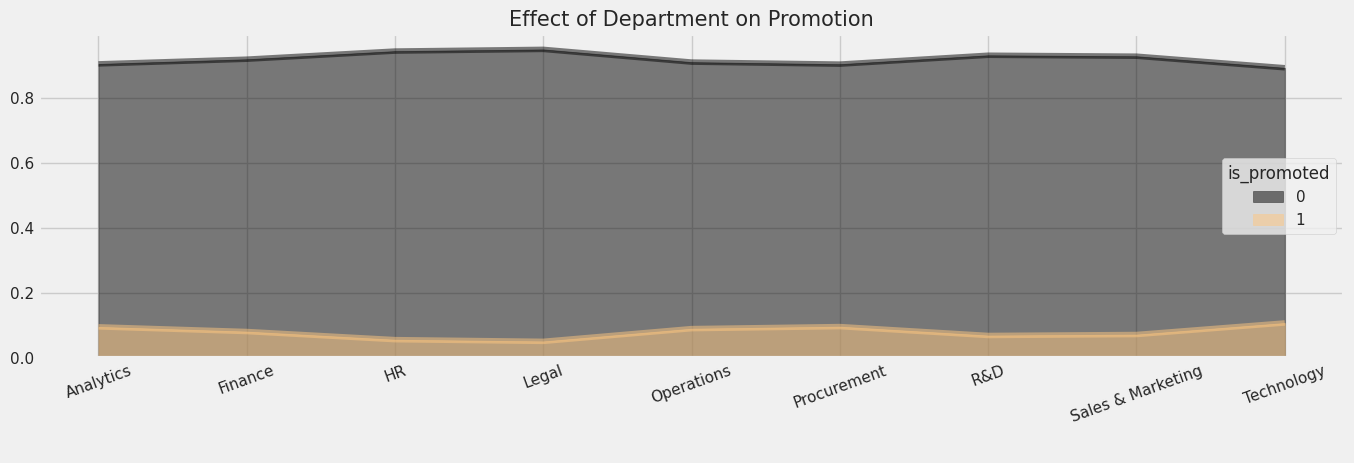

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams['figure.figsize'] = (15, 4)

# Assuming 'train' is your dataframe
# Replace 'train' with your actual dataframe if it has a different name
x = pd.crosstab(train['department'], train['is_promoted'])

# Generate colors for the area plot
colormap = ListedColormap(plt.cm.copper(np.linspace(0, 1, 3)))

# Normalize the values and create an area plot
x.div(x.sum(1).astype(float), axis=0).plot(kind='area', stacked=False, colormap=colormap)

# Set the title and labels
plt.title('Effect of Department on Promotion', fontsize=15)
plt.xticks(rotation=20)
plt.xlabel(' ')

# Show the plot
plt.show()


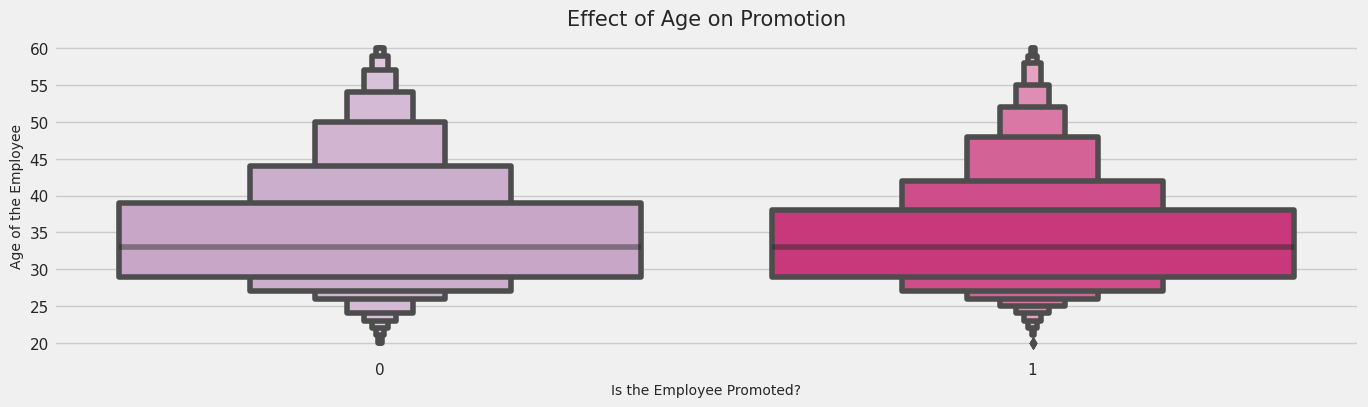

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (15, 4)

# Assuming 'train' is your dataframe
# Replace 'train' with your actual dataframe if it has a different name
sns.boxenplot(x='is_promoted', y='age', data=train, palette='PuRd')

plt.title('Effect of Age on Promotion', fontsize=15)
plt.xlabel('Is the Employee Promoted?', fontsize=10)
plt.ylabel('Age of the Employee', fontsize=10)

plt.show()


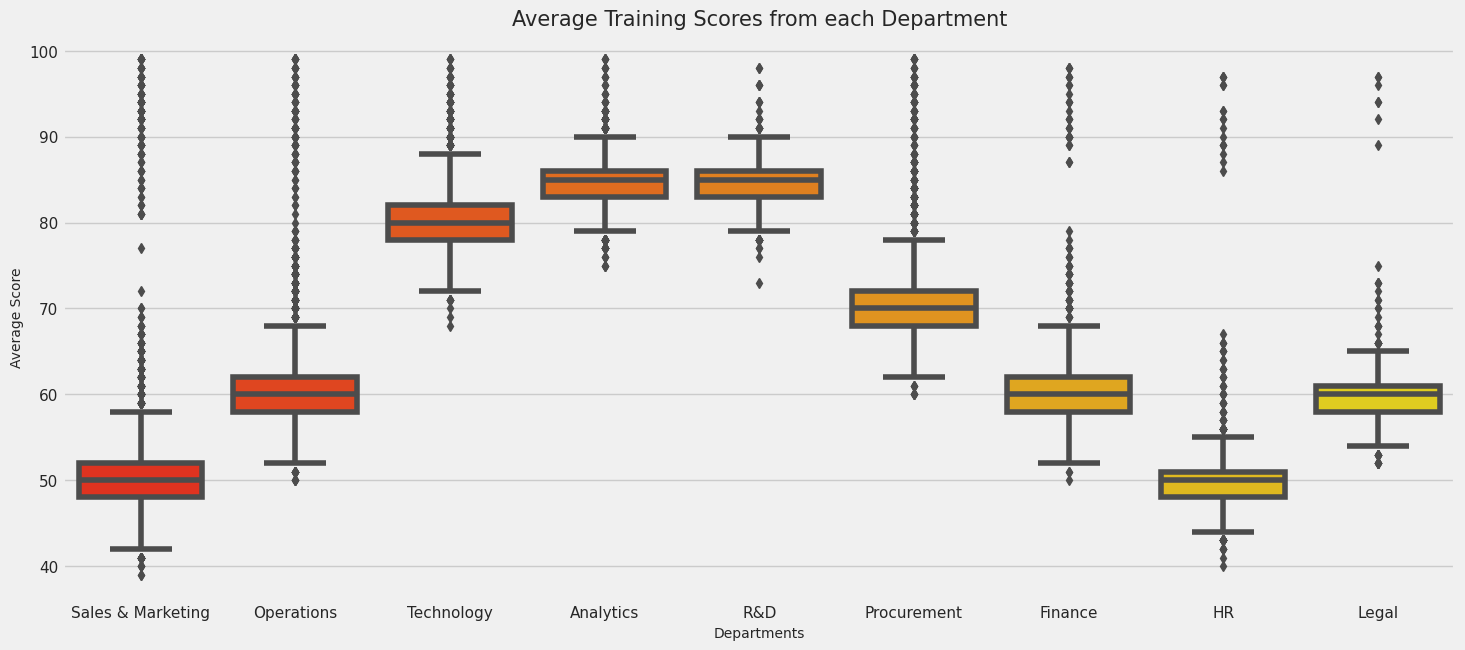

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (16, 7)

# Assuming 'train' is your dataframe
# Replace 'train' with your actual dataframe if it has a different name
sns.boxplot(x=train['department'], y=train['avg_training_score'], palette='autumn')

plt.title('Average Training Scores from each Department', fontsize=15)
plt.ylabel('Average Score', fontsize=10)
plt.xlabel('Departments', fontsize=10)

plt.show()


<ipython-input-51-6e6ea92ca7a9>:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(train.corr(), annot = True, linewidth = 0.5, cmap = 'Wistia')


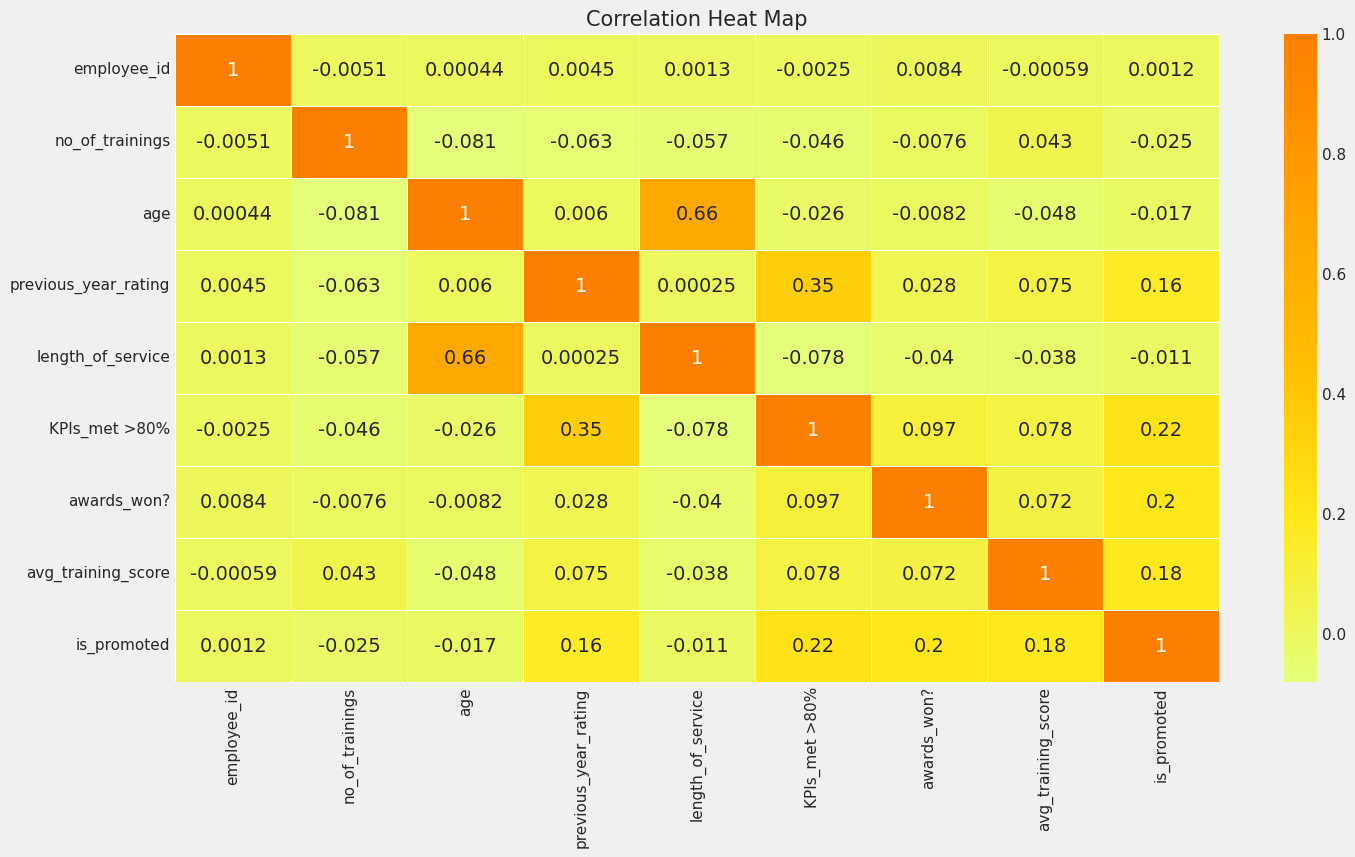

In [ ]:
# lets check the Heat Map for the Data with respect to correlation.

plt.rcParams['figure.figsize'] = (15, 8)
sns.heatmap(train.corr(), annot = True, linewidth = 0.5, cmap = 'Wistia')
plt.title('Correlation Heat Map', fontsize = 15)
plt.show()

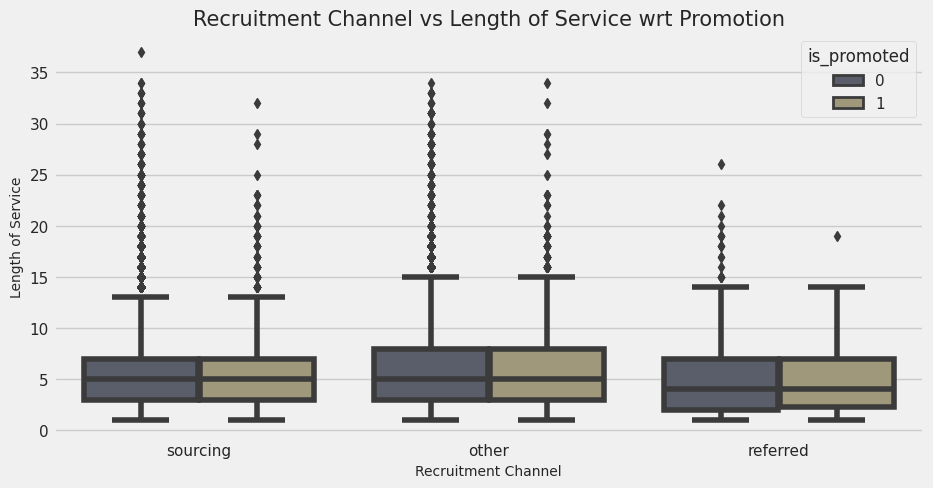

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)

sns.boxplot(x='recruitment_channel',
            y='length_of_service',
            hue='is_promoted',
            data=train,
            palette='cividis')

plt.title('Recruitment Channel vs Length of Service wrt Promotion', fontsize=15)
plt.ylabel('Length of Service', fontsize=10)
plt.xlabel('Recruitment Channel', fontsize=10)
plt.show()


<ipython-input-250-198056157dfe>:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='department', y='is_promoted', hue='awards_won?', data=train, palette='autumn', ci=None)


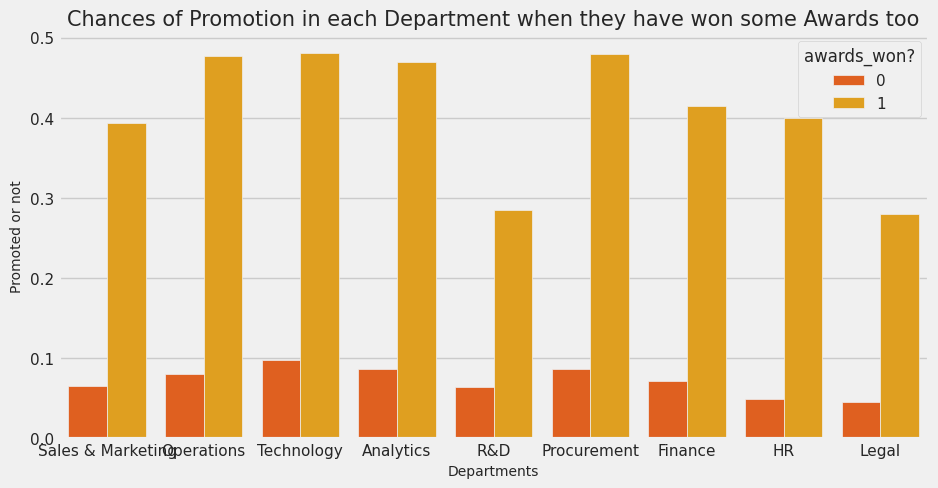

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)

sns.barplot(x='department', y='is_promoted', hue='awards_won?', data=train, palette='autumn', ci=None)

plt.title('Chances of Promotion in each Department when they have won some Awards too', fontsize=15)
plt.ylabel('Promoted or not', fontsize=10)
plt.xlabel('Departments', fontsize=10)
plt.show()


# Grouping and Filtering Operations

In [ ]:
## lets check the relation between KPIs Met and Promotion

x = pd.crosstab(train['KPIs_met >80%'], train['is_promoted'])
x.style.background_gradient(cmap = 'bone')

is_promoted,0,1
KPIs_met >80%,,
0,34111,1406
1,16029,3262


In [ ]:
## lets check the relation between the Awards and Promotion

x = pd.crosstab(train['awards_won?'], train['is_promoted'])
x.style.background_gradient(cmap = 'Blues')

is_promoted,0,1
awards_won?,,
0,49429,4109
1,711,559


In [ ]:
# lets check the no. eployees who won awards from each Department

train[['department', 'awards_won?']].groupby(['department']).agg('sum').sort_values(by = 'awards_won?',
                                                            ascending = False).style.background_gradient('magma')

,awards_won?
department,
Sales & Marketing,361
Operations,262
Technology,185
Procurement,171
Analytics,130
Finance,70
HR,45
Legal,25
R&D,21


Using Interact

Creates user interface (UI) controls for exploring code and data interactively.

In [ ]:

@interact
def check(column=widgets.Dropdown(options=train.select_dtypes('object').columns.tolist()),
          palette=['cividis', 'copper', 'spring', 'Reds', 'Blues']):
    if column is not None:
        sns.countplot(x=train[column], palette=palette)
        plt.title(f'Univariate Chart for {column}')
        plt.show()

interactive(children=(Dropdown(description='column', options=('department', 'region', 'education', 'gender', '…

In [ ]:
# lets group the employees based on their Education

@interact
def group(column = list(train.select_dtypes('object').columns)):
    return train[[column, 'is_promoted']].groupby([column]).agg(['count',
                                                'sum', 'mean','min','max']).style.background_gradient(cmap = 'viridis')

In [ ]:
## lets use the interactive function to make it more reusable

@interact
def group_operations(column = list(train.select_dtypes('object').columns),
                     column2 = list(train.select_dtypes('number').columns)[1:]):
    return train[[column, column2]].groupby([column]).agg('count').style.background_gradient(cmap = 'Wistia')

interactive(children=(Dropdown(description='column', options=('department', 'region', 'education', 'gender', '…

# Data Cleaning

In [ ]:
# Assuming train and test are your dataframes
# Replace them with your actual training and testing datasets

# Calculate the total missing values in the training dataset
train_total = train.isnull().sum()

# Calculate the percentage of missing values in the training dataset
train_percent = ((train.isnull().sum() / train.shape[0]) * 100).round(2)


# Create a dataset consisting of total no. of missing values and percentage of missing values
train_missing_data = pd.concat([train_total, train_percent],
                               axis=1,
                               keys=['Train_Total', 'Train_Percent %', 'Test_Total', 'Test_Percent %'],
                               sort=False)

# Display the missing data summary with color highlighting
train_missing_data.style.bar(color='gold')

,Train_Total,Train_Percent %
employee_id,0,0.000000
department,0,0.000000
region,0,0.000000
education,2409,4.400000
gender,0,0.000000
recruitment_channel,0,0.000000
no_of_trainings,0,0.000000
age,0,0.000000
previous_year_rating,4124,7.520000
length_of_service,0,0.000000


In [ ]:
train['previous_year_rating'].fillna(0,inplace=True)
train['education'].fillna(0,inplace=True)

In [ ]:
train['previous_year_rating'].isnull().sum()
train['education'].isnull().sum()

0

In [ ]:
#Dropping records with education=NULL
train=train.dropna()
train.shape

(54808, 14)

In [ ]:
train.isnull().sum()

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64

In [ ]:
train = train.drop(train[(train['KPIs_met >80%'] == 0) & (train['previous_year_rating'] == 1.0) &
      (train['awards_won?'] == 0) & (train['avg_training_score'] < 60) & (train['is_promoted'] == 1)].index)

# lets check the shape of the train data after deleting the two rows
print("After Deletion of the above two rows :", train.shape)

After Deletion of the above two rows : (54806, 14)


In [ ]:
# lets split the target data from the train data

y_train = train['is_promoted']
x_train = train.drop(['is_promoted'], axis = 1)
x_test = test

# lets print the shapes of these newly formed data sets
print("Shape of the x :", x_train.shape)
print("Shape of the y :", y_train.shape)
print("Shape of the x Test :", x_test.shape)

Shape of the x : (54806, 13)
Shape of the y : (54806,)
Shape of the x Test : (10962, 13)


In [ ]:
x_train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73


In [ ]:
from collections import Counter

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

In [ ]:
!pip install scikit-learn

In [ ]:
train_features_eng = train
train_features_eng = train_features_eng.drop(['employee_id','recruitment_channel','no_of_trainings','gender','length_of_service','region'],axis=1)

In [ ]:
train_features_eng=pd.get_dummies(train_features_eng, columns=["department","education"], prefix=["Dept", "Eduacation"])
train_features_eng.head()

,age,previous_year_rating,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,Dept_Analytics,Dept_Finance,Dept_HR,Dept_Legal,Dept_Operations,Dept_Procurement,Dept_R&D,Dept_Sales & Marketing,Dept_Technology,Eduacation_0,Eduacation_Bachelor's,Eduacation_Below Secondary,Eduacation_Master's & above
0,35,5.0,1,0,49,0,0,0,0,0,0,0,0,1,0,0,0,0,1
1,30,5.0,0,0,60,0,0,0,0,0,1,0,0,0,0,0,1,0,0
2,34,3.0,0,0,50,0,0,0,0,0,0,0,0,1,0,0,1,0,0
3,39,1.0,0,0,50,0,0,0,0,0,0,0,0,1,0,0,1,0,0
4,45,3.0,0,0,73,0,0,0,0,0,0,0,0,0,1,0,1,0,0


In [ ]:
x1 = train_features_eng.drop(["is_promoted"],axis=1)
y1 = train_features_eng.loc[:,"is_promoted"]
x_train,x_test,y_train,y_test=train_test_split(x1,y1,test_size=0.2,random_state=0,stratify=y1)
k_fold = KFold(n_splits=5, shuffle=True, random_state=0)

In [ ]:
Dec_tree=DecisionTreeClassifier(max_depth= 9, max_leaf_nodes= 60, min_samples_leaf= 7, min_samples_split= 2)
Dec_tree.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=9, max_leaf_nodes=60, min_samples_leaf=7)

In [ ]:
prediction = Dec_tree.predict(x_test)

In [ ]:
employee_id=test['employee_id']

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# Sample training data
data = {'employee_id' :employee_id,
        'is_promoted' : prediction }

df_train = pd.DataFrame(data)

# Train a Decision Tree model
model = DecisionTreeClassifier()
model.fit(df_train[['employee_id']], df_train['is_promoted'])

# User input for prediction
user_input = float(input("Enter the value of Employeeid for prediction: "))

# Prepare input data for prediction
new_data = pd.DataFrame({'employee_id': [user_input]})

# Make prediction
prediction = model.predict(new_data)

print("Whether the Employee should get a Promotion : 1-> Promotion, and 0-> No Promotion :", prediction)


Enter the value of Employeeid for prediction: 6545
Whether the Employee should get a Promotion : 1-> Promotion, and 0-> No Promotion : [0]


In [ ]:
prediction_csv_file = pd.DataFrame({'employee_id' : test['employee_id'],'is_promoted' : prediction})

In [ ]:
prediction_csv_file.to_csv('EmployeePredictionList.csv',index=False)